# MIT 6.86x — Project 1  
### Sentiment Analysis with Linear Classifiers  


Ele contempla:
- Problem 2: perceptron_single_step_update  
- Problem 3: perceptron  
- Problem 4: average perceptron  
- Problem 5: Pegasos  


<br>

===========================================  
Imports e configuração
===


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import random
from string import punctuation, digits

# Ajuste do path para acessar os módulos do projeto
sys.path.append("sentiment_analysis")

import utils

# import project1 as p1

<br>

===========================================  
Carregamento dos dados
===

Usamos os arquivos:
- `reviews_train.tsv`
- `reviews_val.tsv`
- `reviews_test.tsv`

dentro de `sentiment_analysis/`.

In [128]:
train_data = utils.load_data('sentiment_analysis/reviews_train.tsv')
val_data = utils.load_data('sentiment_analysis/reviews_val.tsv')
test_data = utils.load_data('sentiment_analysis/reviews_test.tsv')

train_texts, train_labels = zip(*[(d['text'], d['sentiment']) for d in train_data])
val_texts, val_labels = zip(*[(d['text'], d['sentiment']) for d in val_data])
test_texts, test_labels = zip(*[(d['text'], d['sentiment']) for d in test_data])

<br>

===========================================  
Problem 2 — Hinge Loss
===


- ### `get_order`

    - é uma função que retorna uma lista de índices para os pontos de dados em ordem aleatória.  
Ela recebe um inteiro `n_samples` como entrada, que representa o número de amostras no conjunto de dados.  
A função usa o método `random.sample` para gerar uma permutação aleatória dos índices de 0 a `n_samples - 1`.  
Isso é útil para embaralhar os dados antes de treinar ou avaliar um modelo.

In [129]:
def get_order(n_samples):
    try:
        with open('sentiment_analysis/' + str(n_samples) + '.txt') as fp:
            line = fp.readline()
            return list(map(int, line.split(',')))
    except FileNotFoundError:
        random.seed(1)
        indices = list(range(n_samples))
        random.shuffle(indices)
        return indices

- ### `hinge_loss_single`

    - Calcula a perda de dobradiça em um único ponto de dados, dados parâmetros de classificação específicos.  
        - Argumentos:  
            - x   = `feature_vector` - array numpy descrevendo o ponto de dados fornecido.
            -    y   = `label` - float, a classificação correta do ponto de dados.
            -    𝜃   = `theta` - array numpy descrevendo o classificador linear.
            -    𝜃_0 = `theta_0` - float representando o parâmetro de deslocamento.
        - Retorna:
            - a perda de dobradiça, como um float, associada ao ponto de dados e aos parâmetros fornecidos.

$\to\quad z = y(\theta \cdot x + \theta_0)$

$\to\quad \ell_{\text{hinge}}(z) = \max(0, 1 - z)$

In [130]:
def hinge_loss_single(feature_vector, label, theta, theta_0):
    score = np.matmul(theta, feature_vector) + theta_0
    loss = max(0, 1 - label * score)
    return loss

- ### `hinge_loss_full`

    - Calcula a perda de dobradiça para parâmetros de classificação fornecidos, calculada como a média em um conjunto de dados fornecido.
        - Argumentos:
            - `feature_matrix` - matriz numpy que descreve os dados fornecidos. Cada linha representa um único ponto de dados.
            - `labels` - array numpy onde o k-ésimo elemento do array é a classificação correta da k-ésima linha da matriz de características.
            - `theta` - array numpy que descreve o classificador linear.
            - `theta_0` - número real que representa o parâmetro de deslocamento.
        - Retorna:
            - a perda de dobradiça, como um número de ponto flutuante, associada ao conjunto de dados e aos
            - parâmetros fornecidos. Este número deve ser a perda de dobradiça média em todos os dados.


Veja:

- se $z \ge 1$: perda = 0  
- se $z < 1$: perda = $1 - z$

|Hinge Loss Full:|$$\frac{1}{n}\sum_{i=1}^n \max(0, 1 - y^{(i)}(\theta \cdot x^{(i)} + \theta_0))$$|
|-|-|

- onde: $H_L \text(médio) = \sum \frac{H_L \text(individual)}{\text(nº exemplos)}  $



In [131]:
def hinge_loss_full(feature_matrix, labels, theta, theta_0):
    loss_full = 0
    n_samples = feature_matrix.shape[0]
    for i in range(n_samples):
        loss_full += hinge_loss_single(feature_matrix[i], labels[i], theta, theta_0)
    return loss_full / n_samples

<br>

===========================================  
Problem 3 — Perceptron Algorithm
===


- ### `perceptron_single_step_update`

    - Atualiza os parâmetros de classificação `theta` e `theta_0` por meio de uma única etapa do algoritmo do perceptron.  
    Retorna novos parâmetros em vez de modificá-los no local.
        - Argumentos:
            - $x \to$ feature_vector - Um array numpy descrevendo um único ponto de dados.
            - $y \to$ label - A classificação correta do vetor de características.
            - $\theta \to$ current_theta - O valor atual de theta usado pelo algoritmo do perceptron antes desta atualização.
            - $\theta_0 \to$ current_theta_0 - O valor atual de theta_0 usado pelo algoritmo do perceptron antes desta atualização.

        - Retorna uma tupla contendo dois valores:
            - o parâmetro de coeficiente de característica atualizado `theta` como um array numpy
            - o parâmetro de deslocamento atualizado `theta_0` como um número de ponto flutuante

Veja:

- erro significa $\to\quad y(\theta \cdot x + \theta_0) \le 0$ 
    - Se isso acontecer  
$\theta \Leftarrow \theta + y \cdot x$  
$\theta_0 \leftarrow \theta_0 + y$
    - Se não houver erro não atualiza nada

Ou seja:  
$\to\quad \text{score} = (\theta^* \cdot x + \theta^*_0)$


$\to\quad y \cdot \text{score} \le 0  \\
\qquad\to\quad \theta = \theta^* + y \cdot x \\
\qquad\to\quad \theta_0 = \theta^*_0 + y$  

$\to\quad y \cdot \text{score} < 0  \\
\qquad\to\quad \theta = \theta^* \\
\qquad\to\quad \theta_0 = \theta^*_0$

In [132]:
def perceptron_single_step_update(
    feature_vector, label, current_theta, current_theta_0
):

    score = np.matmul(current_theta, feature_vector) + current_theta_0
    if label * score <= 0:
        theta = current_theta + label * feature_vector
        theta_0 = current_theta_0 + label
    else:
        theta = current_theta
        theta_0 = current_theta_0
    return theta, theta_0

- ### `perceptron`

    - Executa o algoritmo completo do perceptron em um conjunto de dados fornecido.  
    Executa T iterações pelo conjunto de dados: não paramos antes do término.

        - Argumentos:
            - `feature_matrix` - matriz numpy que descreve os dados fornecidos. Cada linha representa um único ponto de dados.
            - `labels` - array numpy onde o k-ésimo elemento do array é a classificação correta da k-ésima linha da matriz de características.
            - `T` - inteiro que indica quantas vezes o algoritmo do perceptron deve iterar pela matriz de características.

        - Retorna uma tupla contendo dois valores:
            - o parâmetro de coeficiente de característica `theta` como um array numpy  
            (encontrado após T iterações pela matriz de características)
            - o parâmetro de deslocamento `theta_0` como um número de ponto flutuante  
            (encontrado também após T iterações pela matriz de características).

<br>

>   **NOTA:** Utilize as funções implementadas anteriormente quando aplicável.  
    Não copie e cole código de partes anteriores.

In [133]:
def perceptron(feature_matrix, labels, T):
    n_samples, n_features = feature_matrix.shape
    theta = np.zeros(n_features)
    theta_0 = 0.0

    for t in range(T):
        for i in get_order(n_samples):
            theta, theta_0 = perceptron_single_step_update(
                feature_matrix[i], labels[i], theta, theta_0
            )

    return theta, theta_0

- ### `average_perceptron`

    - Executa o algoritmo do perceptron médio em um conjunto de dados fornecido.  
    Executa `T` iterações pelo conjunto de dados (não paramos antes do término) e, portanto, calcula a média de `T` valores de parâmetros.

        - Argumentos:
            - `feature_matrix` - Uma matriz numpy que descreve os dados fornecidos. Cada linha representa um único ponto de dados.
            - `labels` - Um array numpy onde o k-ésimo elemento do array é a classificação correta da k-ésima linha da matriz de características.
            - `T` - Um inteiro que indica quantas vezes o algoritmo do perceptron deve iterar pela matriz de características.

        - Retorna uma tupla contendo dois valores:
            - o parâmetro de coeficiente de característica médio `theta` como um array numpy  
            (calculado a média de T iterações pela matriz de características)
            - o parâmetro de deslocamento médio `theta_0` como um número de ponto flutuante número  
            (média também calculada em T iterações através da matriz de características).

<br>

>   NOTA: Utilize as funções implementadas anteriormente quando aplicável.  
        Não copie e cole código de partes anteriores.

>   NOTA: É mais difícil manter uma média móvel do que somar e dividir.



In [134]:
def average_perceptron(feature_matrix, labels, T):
    n_samples, n_features = feature_matrix.shape
    theta = np.zeros(n_features)
    theta_0 = 0.0

    theta_soma = np.zeros(n_features)
    theta_0_soma = 0.0
    nT = 0

    for t in range(T):
        for i in get_order(n_samples):
            theta, theta_0 = perceptron_single_step_update(
                feature_matrix[i], labels[i], theta, theta_0
            )
            theta_soma += theta
            theta_0_soma += theta_0
            nT += 1
    theta_med = theta_soma / nT
    theta_0_med = theta_0_soma / nT

    return theta_med, theta_0_med

<br>

===========================================  
Problem 4 — Pegasos Algorithm
===


- ### `pegasos_single_step_update`

    - Atualiza os parâmetros de classificação `theta` e `theta_0` por meio de uma única passagem do algoritmo Pegasos.  
        Retorna novos parâmetros em vez de modificá-los no local.
        
        - Argumentos:
            - x   = `feature_vector` - Um array numpy descrevendo um único ponto de dados.
            - y   = `label` - A classificação correta do vetor de características.
            - 𝜆   = `L` - O valor lambda usado para atualizar os parâmetros.
            - 𝜂   = `eta` - Taxa de aprendizado para atualizar os parâmetros.
            - 𝜃   = `theta` - O valor antigo de theta usado pelo algoritmo Pegasos antes desta atualização.
            - $𝜃_0$ = `theta_0` - O valor antigo de theta_0 usado pelo algoritmo Pegasos antes desta atualização.
        - Retorna:
            - uma tupla onde o primeiro elemento é um array numpy com o valor de theta após a conclusão da atualização anterior e o  
                segundo elemento é um número real com o valor de theta_0 após a conclusão da atualização anterior.


In [135]:
def pegasos_single_step_update(feature_vector, label, L, eta, theta, theta_0):
    theta_novo = (1 - eta * L) * theta
    theta_0_novo = theta_0
    score = label * (np.matmul(theta, feature_vector) + theta_0)

    if score <= 1:
        theta_novo = theta_novo + eta * label * feature_vector
        theta_0_novo = theta_0_novo + eta * label

    return theta_novo, theta_0_novo

- ### `pegasos`

    - Executa o algoritmo Pegasos em um conjunto de dados fornecido.  
    Executa $T$ iterações pelo conjunto de dados, não há necessidade de se preocupar em parar prematuramente.  
    Para cada atualização, defina a **taxa de aprendizado** = $ \frac{1}{\sqrt(t)}  $,  
    onde $t$ é um contador para o número de atualizações realizadas até o momento (entre 1 e $n^T$, inclusive).

       - Argumentos:
           - x  = `feature_matrix` - Uma matriz numpy que descreve os dados fornecidos. Cada linha representa um único ponto de dados.
           - y  = `labels` - Um array numpy onde o k-ésimo elemento do array é a classificação correta da k-ésima linha da matriz de características.
           - T  = `T` - Um inteiro que indica quantas vezes o algoritmo deve iterar pela matriz de características.
           - 𝜆  = `L` - O valor lambda usado para atualizar os parâmetros do algoritmo Pegasos.
        - Retorna:
           - uma tupla 
           - onde o primeiro elemento é um array numpy com o valor de theta, o parâmetro de classificação linear,  
             encontrado após T iterações na matriz de características 
           - e o segundo elemento é um número real com o valor de theta_0, o parâmetro de classificação de deslocamento,  
             encontrado após T iterações na matriz de características.


    NOTE: Utilize as funções implementadas anteriormente quando aplicável.
            Não copie e cole código de partes anteriores.


In [136]:
def pegasos(feature_matrix, labels, T, L):
    n_samples, n_features = feature_matrix.shape
    theta = np.zeros(n_features)
    theta_0 = 0.0
    t = 1

    for _ in range(T):
        for i in get_order(n_samples):
            eta = 1 / np.sqrt(t)
            theta, theta_0 = pegasos_single_step_update(
                feature_matrix[i], labels[i], L, eta, theta, theta_0
            )
            t += 1

    return theta, theta_0

<br>

===========================================  
Utils $\to\quad$ 1 
===


- ### `extract_words`
    - Função auxiliar para `bag_of_words(...)`.

        - Argumentos:
            - uma string `text`.
        - Retorno:
            - uma lista de palavras em minúsculas na string, onde pontuação e dígitos contam como palavras separadas.


In [137]:
def extract_words(text):
    for c in punctuation + digits:
        text = text.replace(c, ' ' + c + ' ')
    return text.lower().split()

- ### `bag_of_words`

    - Argumentos:
        - `texts` - uma lista de strings em linguagem natural.
    - Retorna:
        - um dicionário que mapeia cada palavra presente em `texts` para um índice inteiro único.

>   NOTE: sinta-se à vontade para alterar este código conforme as orientações da Seção 3 (por exemplo,  
    remover stopwords, adicionar bigramas etc.)

In [138]:
def bag_of_words(texts, remove_stopword=None):
    indices_by_word = {}  # mapear cada palavra para um índice inteiro único
    for text in texts:
        word_list = extract_words(text)
        for word in word_list:
            if remove_stopword and word in remove_stopword:
                continue
            if word not in indices_by_word:
                indices_by_word[word] = len(indices_by_word)
    return indices_by_word

- ### `extract_bow_feature_vectors`

    - Argumentos:
        - `reviews` - ​​uma lista de strings em linguagem natural
        - `indices_by_word` - um dicionário de palavras com índices únicos.
    - Retorna:
        - Uma matriz representando cada avaliação por meio de características de saco de palavras. 
        - Esta matriz tem, portanto, formato (n, m), onde n conta as avaliações e m conta as palavras no dicionário.


In [139]:
def extract_bow_feature_vectors(reviews, indices_by_word, binarize=True):
    feature_matrix = np.zeros([len(reviews), len(indices_by_word)], dtype=np.float64)
    for i, text in enumerate(reviews):
        word_list = extract_words(text)
        for word in word_list:
            if word not in indices_by_word:
                continue
            feature_matrix[i, indices_by_word[word]] += 1
    if binarize:
        feature_matrix[feature_matrix > 0] = 1
    return feature_matrix

- ### `classify`

    - Uma função de classificação que usa parâmetros fornecidos para classificar um conjunto de pontos de dados.
        - Argumentos:
            - $x$   = `feature_matrix` - matriz numpy que descreve os dados fornecidos. Cada linha representa um único ponto de dados.
            - $\theta$   = `theta` - array numpy que descreve o classificador linear.
            - $\theta_0$ = `theta_0` - número real que representa o parâmetro de deslocamento.
        - Retorna:
            - um array numpy de 1s e -1s, onde o k-ésimo elemento do array é a classificação prevista da k-ésima linha da matriz de características  
            usando os valores de theta e theta_0 fornecidos.  
            - Se uma previsão for MAIOR QUE zero, ela deve ser considerada uma classificação positiva.


In [140]:
def classify(feature_matrix, theta, theta_0):
    scores = np.matmul(feature_matrix, theta) + theta_0
    return np.where(scores > 0, 1, -1)

- ### `classifier_accuracy`
    - Treina um classificador linear e calcula a acurácia.  
    O classificador é treinado nos dados de treinamento.  
    A acurácia do classificador nos dados de treinamento e validação é então retornada.
    
        - Argumentos:
            - `classifier` - Uma função de aprendizado que recebe argumentos
                (matriz de características, rótulos, **kwargs) e retorna (theta, theta_0)
            - `train_feature_matrix` - Uma matriz numpy que descreve os dados de treinamento.
                Cada linha representa um único ponto de dados.
            - `val_feature_matrix` - Uma matriz numpy que descreve os dados de validação.
                Cada linha representa um único ponto de dados.
            - `train_labels` - Um array numpy onde o k-ésimo elemento do array
                é a classificação correta da k-ésima linha da matriz de características de treinamento.
            - `val_labels` - Um array numpy onde o k-ésimo elemento do array
                é a classificação correta da k-ésima linha da matriz de características de validação.
            - `kwargs` - Argumentos nomeados adicionais para passar ao classificador
                (ex.: T ou L)
        - Retorna:
            - uma tupla na qual o primeiro elemento é a acurácia (escalar) do classificador treinado nos dados de treinamento  
            - e o segundo elemento é a acurácia do classificador treinado nos dados de validação.


In [141]:
def classifier_accuracy(
    classifier,
    train_feature_matrix,
    val_feature_matrix,
    train_labels,
    val_labels,
    **kwargs,
):
    theta, theta_0 = classifier(train_feature_matrix, train_labels, **kwargs)
    train_preds = classify(train_feature_matrix, theta, theta_0)
    val_preds = classify(val_feature_matrix, theta, theta_0)
    train_accuracy = np.mean(train_preds == train_labels)
    val_accuracy = np.mean(val_preds == val_labels)

    return train_accuracy, val_accuracy

- ### `accuracy`
    - Dado um vetor de comprimento N contendo rótulos previstos e alvo,  
    retorna a fração de previsões que estão corretas.


In [142]:
def accuracy(preds, targets):
    return (preds == targets).mean()

- ### `dictionary`

    - Construímos o dicionário a partir dos textos de treino e extraímos as matrizes de features em formato BoW.

In [143]:
dictionary = bag_of_words(train_texts)

train_bow_features = extract_bow_feature_vectors(train_texts, dictionary)
val_bow_features = extract_bow_feature_vectors(val_texts, dictionary)
test_bow_features = extract_bow_feature_vectors(test_texts, dictionary)

In [144]:
toy_features, toy_labels = toy_data = utils.load_toy_data(
    'sentiment_analysis/toy_data.tsv'
)

<br>

===========================================  
Utils $\to\quad$ 2  
===


- ### `tune`

In [156]:
def tune(train_fn, param_vals, train_feats, train_labels, val_feats, val_labels):
    train_accs = np.ndarray(len(param_vals))
    val_accs = np.ndarray(len(param_vals))

    for i, val in enumerate(param_vals):
        theta, theta_0 = train_fn(train_feats, train_labels, val)

        train_preds = classify(train_feats, theta, theta_0)
        train_accs[i] = accuracy(train_preds, train_labels)

        val_preds = classify(val_feats, theta, theta_0)
        val_accs[i] = accuracy(val_preds, val_labels)

    return train_accs, val_accs

- ### `tune_perceptron`

In [157]:
def tune_perceptron(*args):
    return tune(perceptron, *args)

- ### `tune_avg_perceptron`

In [158]:
def tune_avg_perceptron(*args):
    return tune(average_perceptron, *args)

- ### `tune_pegasos_T`

In [159]:
def tune_pegasos_T(best_L, *args):
    def train_fn(features, labels, T):
        return pegasos(features, labels, T, best_L)

    return tune(train_fn, *args)

- ### `tune_pegasos_L`

In [160]:
def tune_pegasos_L(best_T, *args):
    def train_fn(features, labels, L):
        return pegasos(features, labels, best_T, L)

    return tune(train_fn, *args)

- ### `plot_tune_results`
    - Gráfico da precisão da classificação nos dados de treinamento e  
    validação versus vários valores de um hiperparâmetro usado durante o treinamento.


In [165]:
def plot_tune_results(algo_name, param_name, param_vals, acc_train, acc_val):
    # put the data on the plot
    plt.subplots()
    plt.plot(param_vals, acc_train, '-o')
    plt.plot(param_vals, acc_val, '-o')

    # make the plot presentable
    algo_name = ' '.join((word.capitalize() for word in algo_name.split(' ')))
    param_name = param_name.capitalize()
    plt.suptitle('Classification Accuracy vs {} ({})'.format(param_name, algo_name))
    plt.legend(['train', 'val'], loc='upper right', title='Partition')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy (%)')
    plt.show()

- ### `most_explanatory_word`

    - Retorna a palavra associada à característica do modelo de saco de palavras com maior peso.


In [169]:
def most_explanatory_word(theta, wordlist):
    return [word for (theta_i, word) in sorted(zip(theta, wordlist))[::-1]]

<br>

===========================================  
Problem 5 — Algorithm Discussion
===


theta for Perceptron is 3.9173999999999918, 4.164000000000001
theta_0 for Perceptron is -8.0


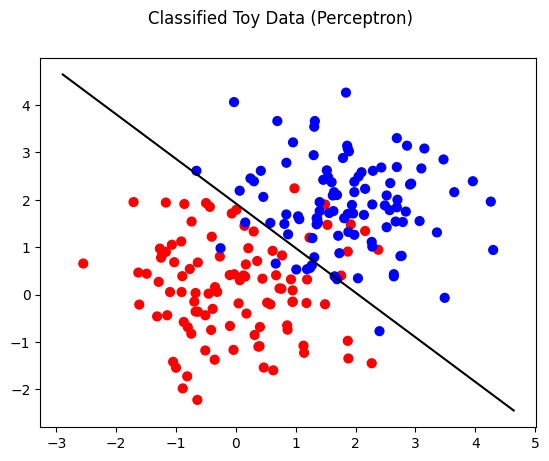

theta for Average Perceptron is 3.47826049999999, 3.611060999999974
theta_0 for Average Perceptron is -6.373


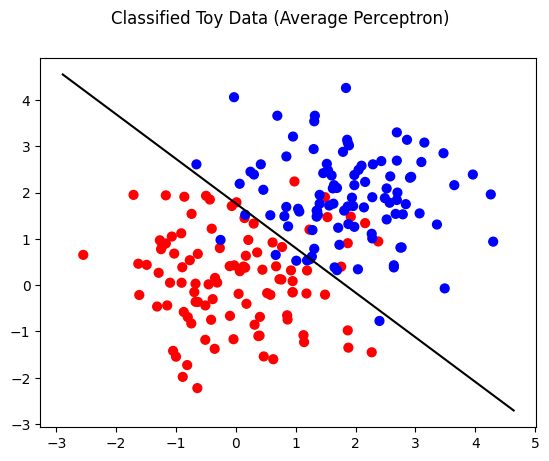

theta for Pegasos is 0.7346463119064065, 0.6300224592973831
theta_0 for Pegasos is -1.2195071848898564


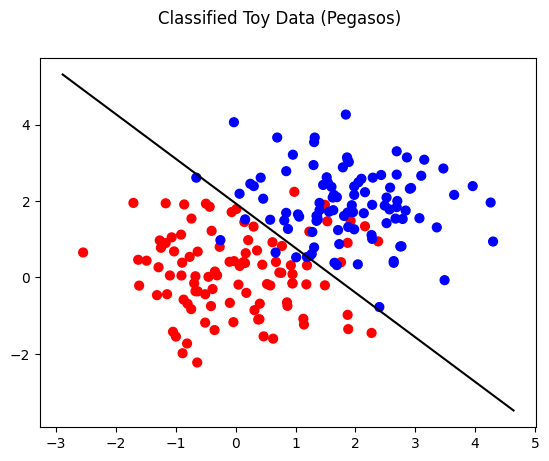

In [145]:
T = 10
L = 0.2

thetas_perceptron = perceptron(toy_features, toy_labels, T)
thetas_avg_perceptron = average_perceptron(toy_features, toy_labels, T)
thetas_pegasos = pegasos(toy_features, toy_labels, T, L)


def plot_toy_results(algo_name, thetas):
    print('theta for', algo_name, 'is', ', '.join(map(str, list(thetas[0]))))
    print('theta_0 for', algo_name, 'is', str(thetas[1]))
    utils.plot_toy_data(algo_name, toy_features, toy_labels, thetas)


plot_toy_results('Perceptron', thetas_perceptron)
plot_toy_results('Average Perceptron', thetas_avg_perceptron)
plot_toy_results('Pegasos', thetas_pegasos)

<br>

===========================================  
Problem 6 — Automative review analyzer
===


<br>

===========================================  
Problem 7 — Classification and Accuracy
===


In [147]:
T = 10
L = 0.01

pct_train_accuracy, pct_val_accuracy = classifier_accuracy(
    perceptron, train_bow_features, val_bow_features, train_labels, val_labels, T=T
)
print("{:35} {:.4f}".format("Training accuracy for perceptron:", pct_train_accuracy))
print("{:35} {:.4f}".format("Validation accuracy for perceptron:", pct_val_accuracy))

avg_pct_train_accuracy, avg_pct_val_accuracy = p1.classifier_accuracy(
    average_perceptron,
    train_bow_features,
    val_bow_features,
    train_labels,
    val_labels,
    T=T,
)
print(
    "{:43} {:.4f}".format(
        "Training accuracy for average perceptron:", avg_pct_train_accuracy
    )
)
print(
    "{:43} {:.4f}".format(
        "Validation accuracy for average perceptron:", avg_pct_val_accuracy
    )
)

avg_peg_train_accuracy, avg_peg_val_accuracy = p1.classifier_accuracy(
    pegasos, train_bow_features, val_bow_features, train_labels, val_labels, T=T, L=L
)
print("{:50} {:.4f}".format("Training accuracy for Pegasos:", avg_peg_train_accuracy))
print("{:50} {:.4f}".format("Validation accuracy for Pegasos:", avg_peg_val_accuracy))

Training accuracy for perceptron:   0.8157
Validation accuracy for perceptron: 0.7160
Training accuracy for average perceptron:   0.9728
Validation accuracy for average perceptron: 0.7980
Training accuracy for Pegasos:                     0.9143
Validation accuracy for Pegasos:                   0.7900


<br>

===========================================  
Problem 8 — Parameter Tuning
===


perceptron valid: [(1, np.float64(0.758)), (5, np.float64(0.72)), (10, np.float64(0.716)), (15, np.float64(0.778)), (25, np.float64(0.794)), (50, np.float64(0.79))]
best = 0.7940, T=25.0000
avg perceptron valid: [(1, np.float64(0.794)), (5, np.float64(0.792)), (10, np.float64(0.798)), (15, np.float64(0.798)), (25, np.float64(0.8)), (50, np.float64(0.796))]
best = 0.8000, T=25.0000
Pegasos valid: tune T [(1, np.float64(0.786)), (5, np.float64(0.78)), (10, np.float64(0.79)), (15, np.float64(0.802)), (25, np.float64(0.806)), (50, np.float64(0.8))]
best = 0.8060, T=25.0000
Pegasos valid: tune L [(0.001, np.float64(0.786)), (0.01, np.float64(0.806)), (0.1, np.float64(0.762)), (1, np.float64(0.568)), (10, np.float64(0.518))]
best = 0.8060, L=0.0100


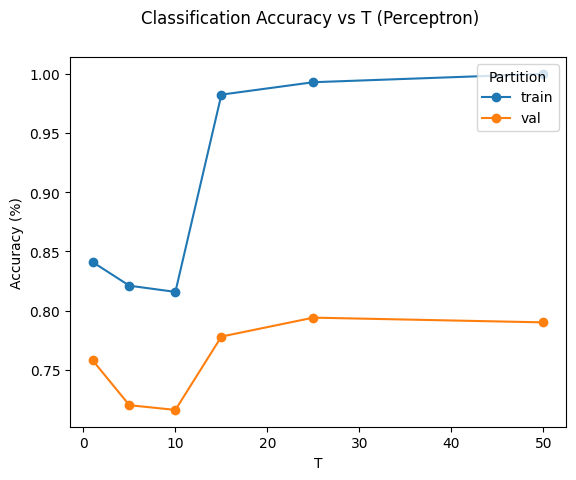

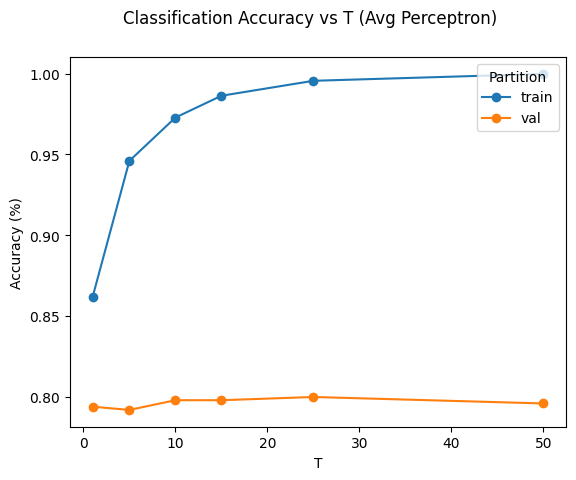

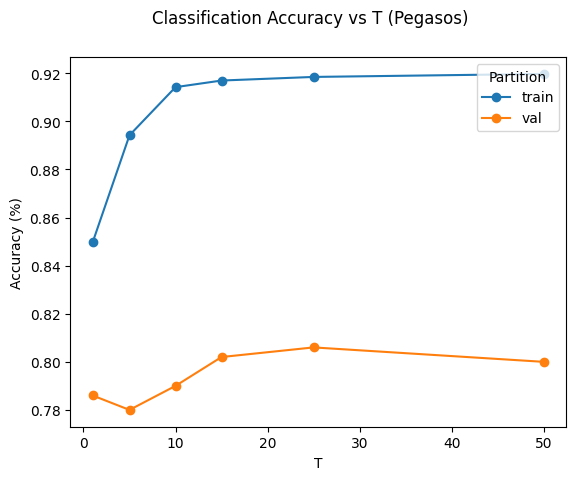

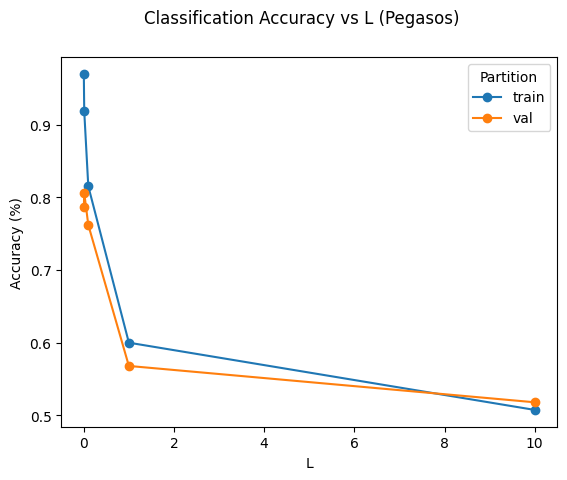

In [166]:
data = (train_bow_features, train_labels, val_bow_features, val_labels)

# values of T and lambda to try
Ts = [1, 5, 10, 15, 25, 50]
Ls = [0.001, 0.01, 0.1, 1, 10]

pct_tune_results = tune_perceptron(Ts, *data)
print('perceptron valid:', list(zip(Ts, pct_tune_results[1])))
print(
    'best = {:.4f}, T={:.4f}'.format(
        np.max(pct_tune_results[1]), Ts[np.argmax(pct_tune_results[1])]
    )
)

avg_pct_tune_results = tune_avg_perceptron(Ts, *data)
print('avg perceptron valid:', list(zip(Ts, avg_pct_tune_results[1])))
print(
    'best = {:.4f}, T={:.4f}'.format(
        np.max(avg_pct_tune_results[1]), Ts[np.argmax(avg_pct_tune_results[1])]
    )
)

# fix values for L and T while tuning Pegasos T and L, respective
fix_L = 0.01
peg_tune_results_T = tune_pegasos_T(fix_L, Ts, *data)
print('Pegasos valid: tune T', list(zip(Ts, peg_tune_results_T[1])))
print(
    'best = {:.4f}, T={:.4f}'.format(
        np.max(peg_tune_results_T[1]), Ts[np.argmax(peg_tune_results_T[1])]
    )
)

fix_T = Ts[np.argmax(peg_tune_results_T[1])]
peg_tune_results_L = tune_pegasos_L(fix_T, Ls, *data)
print('Pegasos valid: tune L', list(zip(Ls, peg_tune_results_L[1])))
print(
    'best = {:.4f}, L={:.4f}'.format(
        np.max(peg_tune_results_L[1]), Ls[np.argmax(peg_tune_results_L[1])]
    )
)

plot_tune_results('Perceptron', 'T', Ts, *pct_tune_results)
plot_tune_results('Avg Perceptron', 'T', Ts, *avg_pct_tune_results)
plot_tune_results('Pegasos', 'T', Ts, *peg_tune_results_T)
plot_tune_results('Pegasos', 'L', Ls, *peg_tune_results_L)

<br>

===========================================  
Problem 9 — Feature Enginnering
===


- ### `Accuracy on the test set`

    - Use o melhor método (perceptron, average perceptron ou Pegasos) 
    - juntamente com os hiperparâmetros ideais de acordo com as acurácias de validação  
    para testar contra o conjunto de dados de teste. 
    - Os dados de teste foram fornecidos como test_bow_features e test_labels.


In [167]:
best_T = 25
best_L = 0.01

theta, theta_0 = pegasos(train_bow_features, train_labels, best_T, best_L)

test_preds = classify(test_bow_features, theta, theta_0)
test_accuracy = np.mean(test_preds == test_labels)
print("Test accuracy: ", test_accuracy)

Test accuracy:  0.802


- ### `The most explanatory unigrams`

    - Atribua a best_theta os pesos (e não o viés!) 
    - aprendidos pelo seu algoritmo mais preciso com a escolha ideal de hiperparâmetros.


In [168]:
best_theta = theta
wordlist = [word for (idx, word) in sorted(zip(dictionary.values(), dictionary.keys()))]
sorted_word_features = utils.most_explanatory_word(best_theta, wordlist)
print("Most Explanatory Word Features")
print(sorted_word_features[:10])

Most Explanatory Word Features
['delicious', 'great', '!', 'best', 'perfect', 'loves', 'wonderful', 'glad', 'love', 'quickly']


- ### `Remove stop words`

    - Remover palavras do conjunto de stopwords e  
    repetir o processo de treinamento, validação e teste.  
    - Compare os resultados com os obtidos anteriormente.


In [171]:
with open("sentiment_analysis/stopwords.txt") as f:
    stopwords = set(w.strip() for w in f.readlines())

dictionary_stopwords = bag_of_words(train_texts, remove_stopword=stopwords)

train_bow_st = extract_bow_feature_vectors(train_texts, dictionary_stopwords)
val_bow_st = extract_bow_feature_vectors(val_texts, dictionary_stopwords)
test_bow_st = extract_bow_feature_vectors(test_texts, dictionary_stopwords)

theta_st, theta_0_st = pegasos(train_bow_st, train_labels, T=25, L=0.01)

test_preds_st = classify(test_bow_st, theta_st, theta_0_st)
test_accuracy_st = np.mean(test_preds_st == test_labels)

print("Test accuracy with stopwords removed: ", test_accuracy_st)

wordlist_st = [
    word
    for (idx, word) in sorted(
        zip(dictionary_stopwords.values(), dictionary_stopwords.keys())
    )
]
sorted_word_features_st = most_explanatory_word(theta_st, wordlist_st)
print("Most Explanatory Word Features with Stopwords Removed")
print(sorted_word_features_st[:10])

Test accuracy with stopwords removed:  0.808
Most Explanatory Word Features with Stopwords Removed
['delicious', 'great', 'loves', '!', 'best', 'perfect', 'excellent', 'wonderful', 'favorite', 'tasty']
